# Демонстрации к лекции 1: как записать задачу и как отдать её SciPy

Ноутбук читается сверху вниз. Каждый пример идёт по одному шаблону:

1. **постановка** словами;
2. **стандартная форма** — та самая табличка $x$, $f$, $g$, $h$ из лекции;
3. **перевод на язык SciPy** — какая функция и какие аргументы;
4. **результат** и картинка.

Сложность нарастает: функция одной переменной → двух переменных → линейный МНК (часть a) → линейное программирование (часть b) → подвешенная цепь, сначала из одного груза (часть c) → невыпуклая функция (часть d). В конце — шпаргалка.

Конспект: [`lecture01.md`](lecture01.md). Те же примеры (a)–(d) одним скриптом без пояснений: [`demo01.py`](demo01.py). Запуск: `uv run jupyter lab` в корне репозитория.

## 0. Пакет `scipy.optimize` одним экраном

`scipy.optimize` — набор готовых солверов. В этой лекции нам нужны три инструмента:

| Задача | Инструмент | Что передаём |
|---|---|---|
| линейный МНК $\min \tfrac12\Vert Ax - y\Vert^2$ | `numpy.linalg.lstsq(A, y)` | матрицу $A$ и вектор $y$ |
| LP $\min c^\top x$ при линейных ограничениях | `scipy.optimize.linprog(c, A_ub=, b_ub=, bounds=)` | коэффициенты, а не функции |
| всё остальное (NLP) | `scipy.optimize.minimize(fun, x0, method=, jac=, constraints=)` | **функцию** $f$, стартовую точку, ограничения |

Соглашения, которые надо запомнить про `minimize`:

- **Всегда минимизирует.** Максимизацию записываем как $\min(-f)$ — сами.
- **`fun` принимает один массив `x` и возвращает одно число.** Даже если переменная одна, `x` — массив длины 1: внутри пишем `x[0]`.
- **`x0` — стартовая точка, обязательна.** Метод итерационный: ему нужно откуда-то начать, и от старта зависит, куда он придёт (часть d).
- **`jac`** — функция, возвращающая градиент $\nabla f(x)$. Необязательна: без неё SciPy оценит производные конечными разностями (лишние вызовы `fun`).
- **`constraints`** — как передать $g(x) = 0$ и $h(x) \ge 0$:

| В лекции | В SciPy |
|---|---|
| $h(x) \ge 0$ | `{"type": "ineq", "fun": h}` — `h` возвращает число или массив, **все компоненты $\ge 0$** |
| $g(x) = 0$ | `{"type": "eq", "fun": g}` |
| линейные $lb \le A x \le ub$ | `LinearConstraint(A, lb, ub)` — то же, но быстрее и без своей функции |
| $a \le x_i \le b$ | `bounds=[(a, b), ...]` |

Знак неравенства в SciPy совпадает с нашим соглашением $h(x) \ge 0$ — повезло.

- **Результат** — объект `OptimizeResult`. Поля, которые смотрим всегда: `x` (найденная точка), `fun` (значение $f$ в ней), `success` и `message` (сошёлся ли и почему остановился), `nit` (итераций), `nfev` (вызовов `fun`).

Методы: `method="BFGS"` для задач без ограничений, `method="SLSQP"` — с ограничениями. Почему именно они — лекции 5 и 13; сейчас достаточно этого правила.

In [1]:
%matplotlib inline

import time

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import LinearConstraint, linprog, minimize

plt.rcParams["figure.dpi"] = 120
rng = np.random.default_rng(1)

## 1. Разминка: функция одной переменной

Минимизируем $f(x) = (x - 2)^2 + 1$. Ответ известен ($x^\ast = 2$, $f^\ast = 1$) — цель здесь не ответ, а познакомиться с интерфейсом.

| | |
|---|---|
| переменные | $x \in \mathbb{R}$, $n = 1$ |
| $f(x)$ | $(x-2)^2 + 1$ |
| $g(x) = 0$ | нет |
| $h(x) \ge 0$ | нет |
| класс | безусловная QP, выпуклая |
| в SciPy | `minimize(f, x0)` |

In [2]:
def f1(x):
    return (x[0] - 2) ** 2 + 1      # x — массив длины 1, поэтому x[0]

res = minimize(f1, x0=[0.0])
res                                 # весь объект результата

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1.0000000000000007
        x: [ 2.000e+00]
      nit: 2
      jac: [-4.470e-08]
 hess_inv: [[ 5.000e-01]]
     nfev: 6
     njev: 3

Построчно:

- `message`, `success` — метод остановился штатно (норма градиента стала меньше порога);
- `fun` — значение $f$ в найденной точке, `x` — сама точка (массив, даже если $n=1$);
- `nit` — число итераций, `nfev` — число вызовов `f1`, `njev` — число вычислений градиента;
- `jac` — градиент в найденной точке (близок к нулю — это и есть критерий остановки);
- `hess_inv` — оценка обратного гессиана, побочный продукт BFGS (лекция 5).

Обратите внимание: `nfev` заметно больше `nit`. Мы не дали градиент, и SciPy на каждой итерации считал его конечными разностями — дополнительными вызовами `f1`. Дадим градиент явно: $f'(x) = 2(x - 2)$.

In [3]:
def df1(x):
    return np.array([2 * (x[0] - 2)])   # градиент — массив той же длины, что x

res_j = minimize(f1, x0=[0.0], jac=df1)
print("без jac: x* = %.6f, итераций %d, вызовов f %d" % (res.x[0], res.nit, res.nfev))
print("с  jac : x* = %.6f, итераций %d, вызовов f %d" % (res_j.x[0], res_j.nit, res_j.nfev))

без jac: x* = 2.000000, итераций 2, вызовов f 6
с  jac : x* = 2.000000, итераций 2, вызовов f 3


## 2. Разминка: квадратичная функция двух переменных

$$f(x) = \tfrac12 x^\top Q x + c^\top x, \qquad Q = \begin{pmatrix} 2 & 0.5 \\ 0.5 & 1 \end{pmatrix}, \quad c = \begin{pmatrix} -1 \\ -1 \end{pmatrix}.$$

| | |
|---|---|
| переменные | $x \in \mathbb{R}^2$ |
| $f(x)$ | $\tfrac12 x^\top Q x + c^\top x$ |
| $g, h$ | нет |
| класс | безусловная QP; $Q \succ 0$ (собственные числа положительны), значит выпуклая |
| в SciPy | `minimize(f, x0, method="BFGS")` — или вообще без SciPy, см. ниже |

Решим двумя способами. Первый — итерационно, `minimize`; через аргумент `callback` соберём все промежуточные точки $x_k$, чтобы нарисовать путь. Второй — «руками»: для выпуклой QP без ограничений минимум там, где $\nabla f = Qx + c = 0$, то есть решение **линейной системы** $Qx = -c$.

In [4]:
Q = np.array([[2.0, 0.5], [0.5, 1.0]])
c = np.array([-1.0, -1.0])

def f2(x):
    return 0.5 * x @ Q @ x + c @ x

path = [np.array([3.0, 2.0])]                       # x0
res = minimize(f2, x0=path[0], method="BFGS", callback=lambda xk: path.append(xk.copy()))
path = np.array(path)

x_lin = np.linalg.solve(Q, -c)                     # Q x = -c
print("minimize:", res.x.round(6), " итераций:", res.nit)
print("solve   :", x_lin.round(6))
print("разница :", np.linalg.norm(res.x - x_lin))

minimize: [0.285714 0.857143]  итераций: 4
solve   : [0.285714 0.857143]
разница : 9.067625461960763e-09


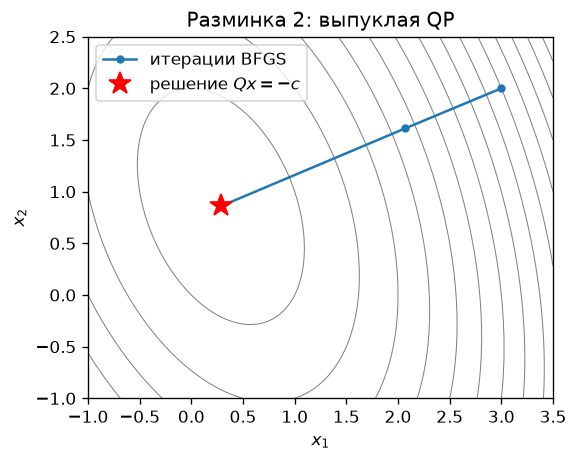

In [5]:
X, Y = np.meshgrid(np.linspace(-1, 3.5, 200), np.linspace(-1, 2.5, 200))
Z = 0.5 * (Q[0, 0] * X**2 + 2 * Q[0, 1] * X * Y + Q[1, 1] * Y**2) + c[0] * X + c[1] * Y

plt.figure(figsize=(5, 4))
plt.contour(X, Y, Z, levels=15, colors="gray", linewidths=0.6)
plt.plot(path[:, 0], path[:, 1], "o-", ms=4, label="итерации BFGS")
plt.plot(*x_lin, "r*", ms=14, label="решение $Qx=-c$")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend(); plt.gca().set_aspect("equal")
plt.title("Разминка 2: выпуклая QP")
plt.show()

### Добавим ограничение

Потребуем $x_1 + x_2 \ge 1.5$. Безусловный минимум $(0.29, 0.86)$ этому не удовлетворяет, значит ограничение будет **активно**: решение ляжет на прямую $x_1 + x_2 = 1.5$.

| | |
|---|---|
| $h(x) \ge 0$ | $h(x) = x_1 + x_2 - 1.5$ |
| класс | QP с одним линейным неравенством, выпуклая |
| в SciPy | `minimize(..., method="SLSQP", constraints=[...])` |

Ограничение линейное, поэтому передаём его как `LinearConstraint(A, lb, ub)`, что означает $lb \le A x \le ub$: здесь $A = (1\ \ 1)$, $lb = 1.5$, $ub = +\infty$. Эквивалентная словарная форма — `{"type": "ineq", "fun": lambda x: x[0] + x[1] - 1.5}`; ниже используем обе и убеждаемся, что результат один.

LinearConstraint: [0.375 1.125]  f = -0.515625
словарь         : [0.375 1.125]  f = -0.515625
h(x*) = x1 + x2 - 1.5 = -0.0 -> ограничение активно


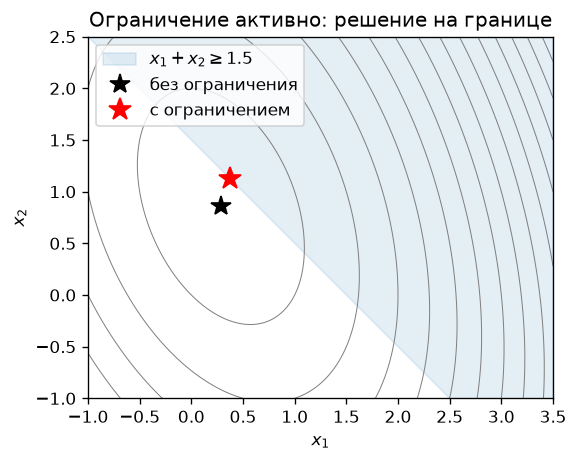

In [6]:
lin = LinearConstraint(np.array([[1.0, 1.0]]), lb=1.5, ub=np.inf)
dic = {"type": "ineq", "fun": lambda x: x[0] + x[1] - 1.5}

res_lin = minimize(f2, x0=[3.0, 2.0], method="SLSQP", constraints=[lin])
res_dic = minimize(f2, x0=[3.0, 2.0], method="SLSQP", constraints=[dic])
print("LinearConstraint:", res_lin.x.round(6), " f =", round(res_lin.fun, 6))
print("словарь         :", res_dic.x.round(6), " f =", round(res_dic.fun, 6))
print("h(x*) = x1 + x2 - 1.5 =", round(res_lin.x.sum() - 1.5, 8), "-> ограничение активно")

plt.figure(figsize=(5, 4))
plt.contour(X, Y, Z, levels=15, colors="gray", linewidths=0.6)
plt.fill_between([-1, 3.5], [2.5, -2], 2.5, color="C0", alpha=0.12, label="$x_1 + x_2 \\geq 1.5$")
plt.plot(*x_lin, "k*", ms=12, label="без ограничения")
plt.plot(*res_lin.x, "r*", ms=14, label="с ограничением")
plt.xlim(-1, 3.5); plt.ylim(-1, 2.5)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend(loc="upper left"); plt.gca().set_aspect("equal")
plt.title("Ограничение активно: решение на границе")
plt.show()

## Часть (a). Линейный метод наименьших квадратов

Есть 40 зашумлённых точек $(t_i, y_i)$; подгоняем полином $\varphi(t; x) = x_1 + x_2 t + x_3 t^2$.

| | |
|---|---|
| переменные | $x = (x_1, x_2, x_3)$ — коэффициенты полинома, $n = 3$ |
| $f(x)$ | $\tfrac12 \sum_i (\varphi(t_i; x) - y_i)^2 = \tfrac12 \Vert A x - y \Vert^2$ |
| $g, h$ | нет |
| класс | безусловная QP, выпуклая (это $\tfrac12 x^\top A^\top A x - \dots$) |
| в SciPy | **не** `minimize`, а `np.linalg.lstsq(A, y)` — для линейной задачи есть прямой метод |

Матрица $A$ (матрица плана) составлена из строк $(1,\ t_i,\ t_i^2)$ — по строке на измерение. `np.vander(t, 3, increasing=True)` строит её за нас.

In [7]:
N = 40
t = np.linspace(0, 1, N)
y_true = 1.0 + 2.0 * t - 3.0 * t**2
y = y_true + 0.15 * rng.standard_normal(N)


def design(t, deg):
    """Матрица плана: столбцы 1, t, t^2, ..., t^deg."""
    return np.vander(t, deg + 1, increasing=True)


A = design(t, 2)
print("A имеет размер", A.shape, "— первые 4 строки (1, t_i, t_i^2):")
print(A[:4].round(3))

A имеет размер (40, 3) — первые 4 строки (1, t_i, t_i^2):
[[1.    0.    0.   ]
 [1.    0.026 0.001]
 [1.    0.051 0.003]
 [1.    0.077 0.006]]


`lstsq` возвращает кортеж из четырёх элементов (решение, сумма квадратов невязок, ранг, сингулярные числа); нам нужен первый — поэтому `x, *_ = ...`. Для сравнения решим и нормальные уравнения $A^\top A\, x = A^\top y$ — так делать **не** рекомендуется, и вот почему.

In [8]:
# 1) QR-подход: numpy.linalg.lstsq (рекомендуемый)
x_lstsq, *_ = np.linalg.lstsq(A, y, rcond=None)
# 2) нормальные уравнения A^T A x = A^T y (только для сравнения)
x_normal = np.linalg.solve(A.T @ A, A.T @ y)

print("истинные коэффициенты      :", np.array([1.0, 2.0, -3.0]))
print("lstsq (QR)                 :", x_lstsq.round(4))
print("нормальные уравнения       :", x_normal.round(4))
print("разница между способами    : %.2e" % np.linalg.norm(x_lstsq - x_normal))
print("cond(A) = %.1e,  cond(A^T A) = %.1e" % (np.linalg.cond(A), np.linalg.cond(A.T @ A)))

истинные коэффициенты      : [ 1.  2. -3.]
lstsq (QR)                 : [ 1.0532  1.7375 -2.7675]
нормальные уравнения       : [ 1.0532  1.7375 -2.7675]
разница между способами    : 4.31e-15
cond(A) = 2.2e+01,  cond(A^T A) = 4.8e+02


Обусловленность $A^\top A$ — квадрат обусловленности $A$: нормальные уравнения теряют вдвое больше верных цифр. При степени 2 это незаметно, при степени 15 — уже критично. Заодно посмотрим на переобучение.

cond(A) при степени 15 = 1.5e+11


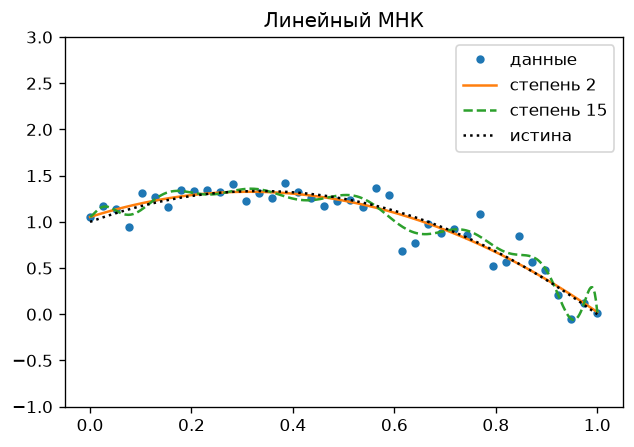

In [9]:
A15 = design(t, 15)
x15, *_ = np.linalg.lstsq(A15, y, rcond=None)
print("cond(A) при степени 15 = %.1e" % np.linalg.cond(A15))

tt = np.linspace(0, 1, 400)
plt.figure(figsize=(6, 4))
plt.plot(t, y, "o", ms=4, label="данные")
plt.plot(tt, design(tt, 2) @ x_lstsq, label="степень 2")
plt.plot(tt, design(tt, 15) @ x15, "--", label="степень 15")
plt.plot(tt, 1 + 2 * tt - 3 * tt**2, ":", color="k", label="истина")
plt.ylim(-1, 3); plt.legend(); plt.title("Линейный МНК")
plt.show()

## Часть (b). LP: планирование производства

Два продукта в количествах $x_1, x_2$, прибыль 3 и 5 за единицу, три цеха с мощностями $x_1 \le 4$, $2x_2 \le 12$, $3x_1 + 2x_2 \le 18$.

| | |
|---|---|
| переменные | $x = (x_1, x_2)$ |
| $f(x)$ | $-3x_1 - 5x_2$ (максимум прибыли = минимум её минуса) |
| $g$ | нет |
| $h(x) \ge 0$ | $(4 - x_1,\; 12 - 2x_2,\; 18 - 3x_1 - 2x_2,\; x_1,\; x_2)$ |
| класс | LP, выпуклая |
| в SciPy | `linprog(c, A_ub=, b_ub=, bounds=)` |

**Перевод на язык `linprog`.** `linprog` решает $\min c^\top x$ при $A_{ub} x \le b_{ub}$ и $lb \le x \le ub$. Значит:

- $f = -3x_1 - 5x_2$ → `c = [-3, -5]`;
- три неравенства «$\le$» — строки `A_ub` и правые части `b_ub`; наши $h \ge 0$ — это те же неравенства с обратным знаком, переписывать ничего не нужно;
- $x \ge 0$ → `bounds=[(0, None), (0, None)]` (`None` = нет верхней границы).

In [10]:
c = np.array([-3.0, -5.0])                     # min -3 x1 - 5 x2
A_ub = np.array([[1.0, 0.0],                    # x1        <= 4
                 [0.0, 2.0],                    #      2 x2 <= 12
                 [3.0, 2.0]])                   # 3 x1 + 2 x2 <= 18
b_ub = np.array([4.0, 12.0, 18.0])

res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=[(0, None), (0, None)], method="highs")
print("статус :", res.message)
print("x*     =", res.x.round(6), "  прибыль =", round(-res.fun, 6))   # минус: возвращаемся к max
print("slack  =", res.slack.round(6), "  (b_ub - A_ub x*: невязка каждого неравенства)")
for i, s in enumerate(res.slack, 1):
    print(f"   ограничение {i}: {'активно' if abs(s) < 1e-9 else 'неактивно, запас %.2f' % s}")

статус : Optimization terminated successfully. (HiGHS Status 7: Optimal)
x*     = [2. 6.]   прибыль = 36.0
slack  = [2. 0. 0.]   (b_ub - A_ub x*: невязка каждого неравенства)
   ограничение 1: неактивно, запас 2.00
   ограничение 2: активно
   ограничение 3: активно


`res.slack` — «запас» каждого неравенства: нулевой запас означает, что ограничение **активно**. Здесь активны цеха 2 и 3, у цеха 1 остаётся 2 единицы мощности. Геометрия: допустимое множество — многоугольник, линии уровня прибыли — параллельные прямые, решение — вершина.

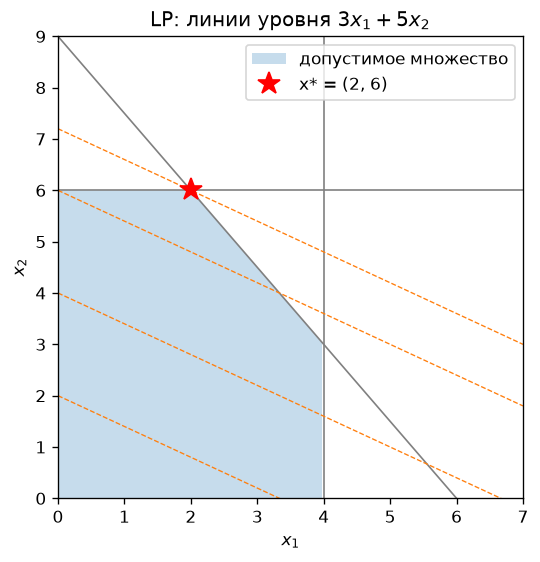

In [11]:
x1 = np.linspace(0, 7, 200)
plt.figure(figsize=(5, 5))
plt.fill_between(x1, 0, np.minimum(6, (18 - 3 * x1) / 2), where=x1 <= 4,
                 alpha=0.25, label="допустимое множество")
plt.axvline(4, color="gray", lw=1); plt.axhline(6, color="gray", lw=1)
plt.plot(x1, (18 - 3 * x1) / 2, color="gray", lw=1)
for val in (10, 20, 30, 36):
    plt.plot(x1, (val - 3 * x1) / 5, "--", lw=0.8, color="C1")
plt.plot(*res.x, "r*", ms=14, label="x* = (2, 6)")
plt.xlim(0, 7); plt.ylim(0, 9)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend(loc="upper right")
plt.title("LP: линии уровня $3x_1 + 5x_2$")
plt.show()

## Часть (c). Подвешенная цепь

Концы цепи закреплены в точках $(-2, 1)$ и $(2, 1)$. Между ними — $N$ грузов на пружинах жёсткости $D$ (длина покоя ноль). Цепь принимает форму с **наименьшей потенциальной энергией**: упругая энергия пружин $\tfrac12 D \cdot (\text{длина})^2$ плюс энергия тяжести $m g z$ каждого груза. Это оптимизационная задача, и мы построим её постепенно: один груз, три груза, сорок.

### Шаг 1. Один груз

Груз в точке $(y_1, z_1)$, две пружины — к левому и правому концу.

$$E(y_1, z_1) = \tfrac12 D \Big[ \underbrace{(y_1 + 2)^2 + (z_1 - 1)^2}_{\text{левая пружина}} + \underbrace{(2 - y_1)^2 + (1 - z_1)^2}_{\text{правая пружина}} \Big] + m g\, z_1 .$$

| | |
|---|---|
| переменные | $x = (y_1, z_1)$, $n = 2$ — координаты груза |
| $f(x)$ | $E(y_1, z_1)$ |
| $g, h$ | нет |
| класс | безусловная QP (энергия квадратична по координатам), выпуклая — **ровно как разминка 2** |
| в SciPy | `minimize(E, x0)` |

Ответ можно получить руками: $\partial E / \partial y_1 = D(y_1 + 2) - D(2 - y_1) = 2 D y_1 = 0 \Rightarrow y_1 = 0$; $\partial E/\partial z_1 = 2D(z_1 - 1) + mg = 0 \Rightarrow z_1 = 1 - \dfrac{mg}{2D}$. Сверим.

In [12]:
D = 70.0                 # жёсткость пружины, Н/м
g = 9.81
p_left, p_right = np.array([-2.0, 1.0]), np.array([2.0, 1.0])
m = 4.0                  # масса груза, кг (вся цепь весит 4 кг)


def E1(x):
    y1, z1 = x
    left = (y1 - p_left[0]) ** 2 + (z1 - p_left[1]) ** 2
    right = (y1 - p_right[0]) ** 2 + (z1 - p_right[1]) ** 2
    return 0.5 * D * (left + right) + m * g * z1


res = minimize(E1, x0=[0.0, 0.0])
print("minimize    : y1 = %.4f, z1 = %.4f" % tuple(res.x))
print("аналитически: y1 = 0,      z1 = %.4f" % (1 - m * g / (2 * D)))

minimize    : y1 = 0.0000, z1 = 0.7197
аналитически: y1 = 0,      z1 = 0.7197


**Добавим пол.** Пусть груз не может опускаться ниже наклонной плоскости $z = 0.5 + 0.1 y$. Это одно неравенство:

| | |
|---|---|
| $h(x) \ge 0$ | $h(y_1, z_1) = z_1 - 0.1 y_1 - 0.5$ |
| класс | QP с одним линейным неравенством |
| в SciPy | `minimize(E, x0, method="SLSQP", constraints=[{"type": "ineq", "fun": h}])` |

При массе 4 кг груз висит на высоте $0.72 > 0.5$ — до пола не достаёт, ограничение **неактивно**, ответ не меняется. Возьмём груз тяжелее, 10 кг: без пола он провис бы до $0.30$, а пол не пускает — ограничение станет **активным**, и $h(x^\ast) = 0$.

In [13]:
def floor1(x):
    y1, z1 = x
    return z1 - 0.1 * y1 - 0.5          # >= 0 означает «над полом»

for m in (4.0, 10.0):
    free = minimize(E1, x0=[0.0, 0.0])
    con = minimize(E1, x0=[0.0, 0.0], method="SLSQP", constraints=[{"type": "ineq", "fun": floor1}])
    print(f"m = {m:4.1f} кг: без пола z1 = {free.x[1]: .3f};  с полом z1 = {con.x[1]: .3f},  "
          f"h(x*) = {floor1(con.x): .2e} -> {'активно' if abs(floor1(con.x)) < 1e-6 else 'неактивно'}")
m = 4.0

m =  4.0 кг: без пола z1 =  0.720;  с полом z1 =  0.720,  h(x*) =  2.20e-01 -> неактивно
m = 10.0 кг: без пола z1 =  0.299;  с полом z1 =  0.498,  h(x*) = -9.48e-13 -> активно


### Шаг 2. Три груза

Теперь грузов три, пружин четыре (концы — груз 1 — груз 2 — груз 3 — концы). Переменных шесть, и `minimize` хочет получить их **одним вектором**. Договоримся о порядке: сначала все $y$, потом все $z$:

```
v = [ y1, y2, y3, z1, z2, z3 ]
      0   1   2   3   4   5      <- индексы в массиве
```

Функция `unpack(v)` восстанавливает из этого вектора две цепочки координат и **добавляет к ним закреплённые концы** — тогда `np.diff` считает разности между всеми соседями, то есть длины всех четырёх пружин.

$$E(v) = \tfrac12 D \sum_{i=0}^{N} \big[(y_{i+1} - y_i)^2 + (z_{i+1} - z_i)^2\big] + m g \sum_{i=1}^{N} z_i, \qquad (y_0, z_0),\ (y_{N+1}, z_{N+1}) \text{ — концы}.$$

| | |
|---|---|
| переменные | $v \in \mathbb{R}^{2N}$, $N = 3$ |
| $f(v)$ | $E(v)$ — формула выше |
| $g$ | нет |
| $h(v) \ge 0$ | $h_i(v) = z_i - 0.1\, y_i - 0.5$, $i = 1, 2, 3$ — по одному неравенству на груз |
| класс | QP с линейными неравенствами, выпуклая |
| в SciPy | `minimize(energy, v0, method="SLSQP", constraints=[...])` |

Масса одного груза — `M_TOTAL / N`, чтобы вся цепь весила `M_TOTAL` кг независимо от числа грузов.

In [14]:
def unpack(v):
    """v = [y_1..y_N, z_1..z_N]  ->  массивы y и z длины N+2 с закреплёнными концами."""
    N = len(v) // 2
    y = np.concatenate(([p_left[0]], v[:N], [p_right[0]]))
    z = np.concatenate(([p_left[1]], v[N:], [p_right[1]]))
    return y, z


M_TOTAL = 4.0            # масса всей цепи, кг; масса одного груза = M_TOTAL / N


def energy(v):
    y, z = unpack(v)
    N = len(v) // 2
    m = M_TOTAL / N
    spring = 0.5 * D * np.sum(np.diff(y) ** 2 + np.diff(z) ** 2)   # 1/2 D * сумма квадратов длин пружин
    gravity = m * g * np.sum(z[1:-1])                             # m g * сумма высот грузов (без концов)
    return spring + gravity


def straight_line(N):
    """Стартовая точка: грузы равномерно на отрезке между концами."""
    ys = np.linspace(p_left[0], p_right[0], N + 2)[1:-1]
    zs = np.linspace(p_left[1], p_right[1], N + 2)[1:-1]
    return np.concatenate((ys, zs))


N = 3
v0 = straight_line(N)
print("v0 =", v0.round(3))
print("энергия в стартовой точке:", round(energy(v0), 4))

v0 = [-1.  0.  1.  1.  1.  1.]
энергия в стартовой точке: 179.24


Ограничения «над полом» для всех грузов сразу. Первый способ — словарь: функция возвращает **массив** из $N$ чисел, и SciPy требует, чтобы все они были $\ge 0$. Второй — `LinearConstraint(A, lb, ub)`: те же неравенства в виде $0.5 \le A v$, где строка $i$ матрицы $A$ содержит $-0.1$ на позиции $y_i$ и $1$ на позиции $z_i$. Напечатаем $A$, чтобы увидеть это глазами.

In [15]:
floor_dict = {"type": "ineq", "fun": lambda v: v[N:] - 0.1 * v[:N] - 0.5}   # z_i - 0.1 y_i - 0.5 >= 0

A_floor = np.hstack((-0.1 * np.eye(N), np.eye(N)))                          # строка i: [-0.1 на y_i, 1 на z_i]
floor_lin = LinearConstraint(A_floor, lb=0.5 * np.ones(N), ub=np.inf)       # 0.5 <= A v < inf
print("A_floor (N = 3), столбцы = [y1 y2 y3 z1 z2 z3]:")
print(A_floor)

r_free = minimize(energy, v0, method="BFGS")
r_dict = minimize(energy, v0, method="SLSQP", constraints=[floor_dict])
r_lin = minimize(energy, v0, method="SLSQP", constraints=[floor_lin])
print("\nбез пола         : E = %.4f, z = %s" % (r_free.fun, r_free.x[N:].round(3)))
print("с полом (словарь): E = %.4f, z = %s" % (r_dict.fun, r_dict.x[N:].round(3)))
print("с полом (Linear) : E = %.4f, z = %s" % (r_lin.fun, r_lin.x[N:].round(3)))
print("h(v*) =", (A_floor @ r_lin.x - 0.5).round(4), "-> нулевые компоненты = активные ограничения")

A_floor (N = 3), столбцы = [y1 y2 y3 z1 z2 z3]:
[[-0.1 -0.  -0.   1.   0.   0. ]
 [-0.  -0.1 -0.   0.   1.   0. ]
 [-0.  -0.  -0.1  0.   0.   1. ]]

без пола         : E = 173.1298, z = [0.72  0.626 0.72 ]
с полом (словарь): E = 173.1298, z = [0.72  0.626 0.72 ]
с полом (Linear) : E = 173.1298, z = [0.72  0.626 0.72 ]
h(v*) = [0.3197 0.1263 0.1197] -> нулевые компоненты = активные ограничения


Все три способа дали одно и то же, и все $h_i(v^\ast) > 0$: цепь из трёх грузов общей массой 4 кг провисает лишь до $z \approx 0.63$ и до пола не достаёт — ограничения **неактивны**, и ответ совпадает с безусловным. Так и должно быть: неактивное ограничение ничего не меняет. Утяжелим цепь до 10 кг (как в шаге 1) — тогда часть грузов ляжет на пол.

In [16]:
M_TOTAL = 10.0
r_free = minimize(energy, v0, method="BFGS")
r_lin = minimize(energy, v0, method="SLSQP", constraints=[floor_lin], options={"ftol": 1e-12})
h_star = A_floor @ r_lin.x - 0.5
print("без пола: z =", r_free.x[N:].round(3))
print("с полом : z =", r_lin.x[N:].round(3))
print("h(v*)   =", h_star.round(4), "-> активны ограничения", np.where(np.abs(h_star) < 1e-6)[0] + 1)

без пола: z = [0.299 0.066 0.299]
с полом : z = [0.514 0.496 0.597]
h(v*)   = [0.1164 0.     0.    ] -> активны ограничения [2 3]


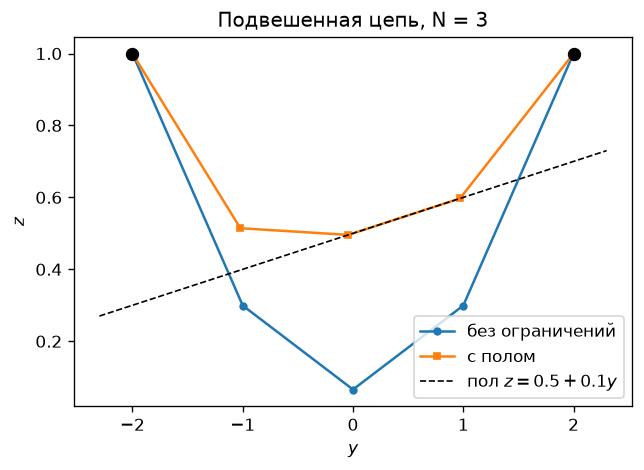

In [17]:
def plot_chain(r_free, r_con, N):
    y1, z1 = unpack(r_free.x)
    y2, z2 = unpack(r_con.x)
    yy = np.array([-2.3, 2.3])
    plt.figure(figsize=(6, 4))
    plt.plot(y1, z1, "o-", ms=4, label="без ограничений")
    plt.plot(y2, z2, "s-", ms=4, label="с полом")
    plt.plot(yy, 0.5 + 0.1 * yy, "k--", lw=1, label="пол $z = 0.5 + 0.1y$")
    plt.plot([-2, 2], [1, 1], "ko", ms=7)
    plt.xlabel("$y$"); plt.ylabel("$z$"); plt.legend()
    plt.title("Подвешенная цепь, N = %d" % N)
    plt.show()

plot_chain(r_free, r_lin, N)

### Шаг 3. Сорок грузов

Меняем только `N` (и возвращаем массу 4 кг — сорок грузов провисают до пола и без утяжеления). Функции `unpack`, `energy`, матрица `A_floor` — те же самые: они написаны для любого $N$. Это главное преимущество векторной записи: задача с 80 переменными и 40 ограничениями пишется так же, как с 6 и 3.

без пола: успех=True, итераций=85, E=13.4417, самая низкая точка z=-1.943
с полом : успех=True, итераций=314, E=38.2721, активных ограничений=25 из 40


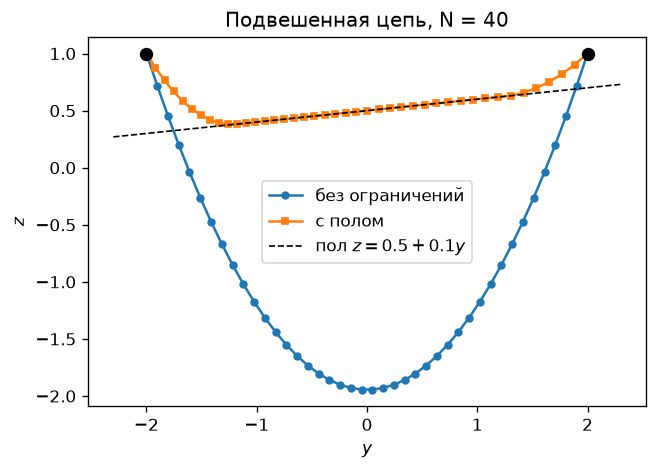

In [18]:
N = 40
M_TOTAL = 4.0                        # возвращаем массу 4 кг: при 40 грузах цепь и так провисает до пола
v0 = straight_line(N)
A_floor = np.hstack((-0.1 * np.eye(N), np.eye(N)))
floor_lin = LinearConstraint(A_floor, lb=0.5 * np.ones(N), ub=np.inf)

r_free = minimize(energy, v0, method="BFGS")
r_con = minimize(energy, v0, method="SLSQP", constraints=[floor_lin], options={"ftol": 1e-12, "maxiter": 500})
active = np.abs(A_floor @ r_con.x - 0.5) < 1e-6
print("без пола: успех=%s, итераций=%d, E=%.4f, самая низкая точка z=%.3f"
      % (r_free.success, r_free.nit, r_free.fun, r_free.x[N:].min()))
print("с полом : успех=%s, итераций=%d, E=%.4f, активных ограничений=%d из %d"
      % (r_con.success, r_con.nit, r_con.fun, active.sum(), N))
plot_chain(r_free, r_con, N)

Активных ограничений 25 из 40: средняя часть цепи лежит на полу, крайние грузы висят в воздухе. Какие ограничения активны, заранее не известно — это одна из главных трудностей задач с неравенствами (часть IV курса).

<details>
<summary>Для любознательных: зачем нужен градиент</summary>

Мы не давали `jac`, и SciPy оценивал градиент конечными разностями: для 80 переменных это ~80 лишних вызовов `energy` на каждой итерации. Градиент энергии выписывается в две строки: производная по $p_i = (y_i, z_i)$ равна $D(2p_i - p_{i-1} - p_{i+1})$ плюс $mg$ по $z$. Сравним число вызовов и время.

</details>

In [19]:
def grad(v):
    y, z = unpack(v)
    N = len(v) // 2
    m = M_TOTAL / N
    gy = D * (2 * y[1:-1] - y[:-2] - y[2:])
    gz = D * (2 * z[1:-1] - z[:-2] - z[2:]) + m * g
    return np.concatenate((gy, gz))

for label, jac in (("без jac", None), ("с jac  ", grad)):
    t0 = time.perf_counter()
    r = minimize(energy, v0, jac=jac, method="SLSQP", constraints=[floor_lin], options={"ftol": 1e-12, "maxiter": 500})
    print(f"{label}: E = {r.fun:.4f}, итераций {r.nit:3d}, вызовов energy {r.nfev:5d}, время {time.perf_counter() - t0:.2f} с")

без jac: E = 38.2721, итераций 314, вызовов energy 27217, время 2.68 с


с jac  : E = 38.2721, итераций  77, вызовов energy   194, время 0.63 с


## Часть (d). Невыпуклая функция: результат зависит от старта

$f(x) = (x^2 - 1)^2 + 0.3x$ — две ямы разной глубины.

| | |
|---|---|
| переменные | $x \in \mathbb{R}$ |
| $f(x)$ | $(x^2-1)^2 + 0.3x$ |
| $g, h$ | нет |
| класс | безусловная NLP, **невыпуклая** |
| в SciPy | `minimize(f, x0, method="BFGS")` — тот же вызов, что в разминке 1 |

Вызов тот же, что в разминке 1, а поведение другое: ответ зависит от `x0`.

In [20]:
def f(x):
    return (x**2 - 1) ** 2 + 0.3 * x


def df(x):
    return 4 * x * (x**2 - 1) + 0.3


results = {}
for x0 in (-1.5, 0.3, 1.5):
    r = minimize(lambda v: f(v[0]), [x0], jac=lambda v: [df(v[0])], method="BFGS")
    results[x0] = (r.x[0], r.fun)
    print("x0 = %5.2f  ->  x* = %8.5f,  f(x*) = %8.5f" % (x0, r.x[0], r.fun))

x0 = -1.50  ->  x* = -1.03558,  f(x*) = -0.30543
x0 =  0.30  ->  x* =  0.96015,  f(x*) =  0.29415
x0 =  1.50  ->  x* =  0.96015,  f(x*) =  0.29415


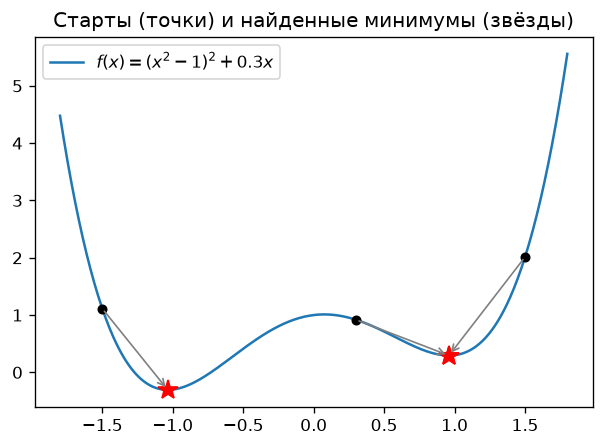

In [21]:
xs = np.linspace(-1.8, 1.8, 400)
plt.figure(figsize=(6, 4))
plt.plot(xs, f(xs), label="$f(x) = (x^2-1)^2 + 0.3x$")
for x0, (xs_, fs_) in results.items():
    plt.plot(x0, f(x0), "ko", ms=5)
    plt.plot(xs_, fs_, "r*", ms=12)
    plt.annotate("", xy=(xs_, fs_), xytext=(x0, f(x0)), arrowprops=dict(arrowstyle="->", color="gray"))
plt.legend(); plt.title("Старты (точки) и найденные минимумы (звёзды)")
plt.show()

Метод не ошибается — он находит *какой-то* локальный минимум. Самый простой способ поискать глобальный — **мультистарт**: запустить из многих случайных точек и взять лучший результат. В одномерном случае это работает; почему не работает при $n = 100$ — упражнение 10.5 конспекта и задача 3(в) домашнего задания.

In [22]:
starts = rng.uniform(-1.8, 1.8, 20)
found = np.array([minimize(lambda v: f(v[0]), [x0], jac=lambda v: [df(v[0])], method="BFGS").x[0] for x0 in starts])
uniq, counts = np.unique(found.round(4), return_counts=True)
for x_star, k in zip(uniq, counts):
    print(f"минимум x* = {x_star: .4f}, f = {f(x_star): .4f}: пришли {k} стартов из {len(starts)}")
print("лучший:", uniq[np.argmin(f(uniq))])

минимум x* = -1.0356, f = -0.3054: пришли 9 стартов из 20
минимум x* =  0.9601, f =  0.2941: пришли 11 стартов из 20
лучший: -1.0356


## Шпаргалка

| Класс задачи | Инструмент | Ключевые аргументы | Что читать в результате |
|---|---|---|---|
| линейный МНК $\min\tfrac12\Vert Ax-y\Vert^2$ | `np.linalg.lstsq(A, y, rcond=None)` | матрица плана $A$ | первый элемент кортежа — $x^\ast$ |
| LP | `linprog(c, A_ub=, b_ub=, A_eq=, b_eq=, bounds=)` | коэффициенты; неравенства только в форме $\le$ | `x`, `fun`, `slack` (0 = активно), `message` |
| NLP без ограничений | `minimize(f, x0, method="BFGS", jac=)` | функция + старт; `jac` по желанию | `x`, `fun`, `success`, `nit`, `nfev` |
| NLP с ограничениями | `minimize(f, x0, method="SLSQP", constraints=[...], bounds=)` | `{"type": "ineq"/"eq", "fun": ...}` или `LinearConstraint(A, lb, ub)` | те же + проверить $h(x^\ast)$ вручную: нули = активные |
| нелинейный МНК (лекция 5) | `least_squares(r, x0)` | функция невязок $r(x)$, не сумма квадратов | `x`, `cost` |

Три типичные ошибки:

1. **Забыли знак при максимизации.** `minimize` и `linprog` всегда минимизируют; для $\max f$ передаём $-f$ и меняем знак у `fun` обратно.
2. **`fun` вернула массив, а не число** — например, `(x - 2) ** 2 + 1` без `x[0]`. Ошибка выглядит как «setting an array element with a sequence» или «The user-provided objective function must return a scalar value».
3. **Неудачный `x0`.** Нет стартовой точки — нет запуска; далёкий или «плохой» старт в невыпуклой задаче приводит не в тот минимум (часть d), а в задаче с ограничениями может замедлить сходимость. Хороший старт — часть постановки.